#CNN Foundations: Convolution/ Spatial Arithmetic / Receptive Field

Author: Michael Mizzi
Date:   14/05/2026

##Scope

This notebook is designed to show step-by-step computations of convolution arithmetic.
The example described in the sudy notes is set-up and worked out throughout the following sections.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

## Setup

Input ($I$): $5 \times 5$ matrix.

Kernel ($K$): $2 \times 2$ matrix.

Stride ($S$): $1$.

Padding ($P$): $1$.

Dilation ($D$): $2$ (increases the effective footprint of the kernel).

Input Matrix ($I$):$$\begin{bmatrix}
6 & 3 & 7 & 4 & 6 \\
9 & 2 & 6 & 7 & 4 \\
3 & 7 & 7 & 2 & 5 \\
4 & 1 & 7 & 5 & 1 \\
4 & 0 & 9 & 5 & 8
\end{bmatrix}$$Kernel ($K$):$$\begin{bmatrix}
-2 & 0 \\
0 & -1
\end{bmatrix}$$


In [2]:
I = np.array([
    [6, 3, 7, 4, 6],
    [9, 2, 6, 7, 4],
    [3, 7, 7, 2, 5],
    [4, 1, 7, 5, 1],
    [4, 0, 9, 5, 8]
])

K = np.array([
    [-2, 0],
    [0, -1]
])

print("Input Matrix I:")
print(I)
print("\nKernel K:")
print(K)

Input Matrix I:
[[6 3 7 4 6]
 [9 2 6 7 4]
 [3 7 7 2 5]
 [4 1 7 5 1]
 [4 0 9 5 8]]

Kernel K:
[[-2  0]
 [ 0 -1]]


## Spatial Arithmetic

The Effective Kernel Size ($K_{eff}$) due to dilation ($D=2$) is represented as follows:

$$K_{eff} = K + (K-1)(D-1) = 2 + (2-1)(2-1) = 3$$

The kernel behaves like a $3 \times 3$ filter where only the corners contain the weights:

$$\text{Effective Kernel} = \begin{bmatrix} -2 & \cdot & 0 \\ \cdot & \cdot & \cdot \\ 0 & \cdot & -1 \end{bmatrix}$$

Based on the above kernel and dilation adjustments the Output Dimensions ($O$) is equal to:

$$O = \frac{I + 2P - K_{eff}}{S} + 1 = \frac{5 + 2(1) - 3}{1} + 1 = 5$$

Thus the output is a $5 \times 5$ matrix.

In [3]:
# Define stride, padding, and dilation based on the setup
S = 1 # Stride
P = 1 # Padding
D = 2 # Dilation

# Original kernel size (assuming square kernel K.shape[0])
K_original = K.shape[0]

# Calculate Effective Kernel Size (K_eff)
K_eff = K_original + (K_original - 1) * (D - 1)
print(f"Effective Kernel Size (K_eff): {K_eff}")

# Input size (assuming square input I.shape[0])
I_size = I.shape[0]

# Calculate Output Dimensions (O)
O = (I_size + 2 * P - K_eff) / S + 1
print(f"Output Dimensions (O): {int(O)}x{int(O)}")

Effective Kernel Size (K_eff): 3
Output Dimensions (O): 5x5


## The adjusted input

The input marix is adjusted by adding the padding at the border to reflect `p=1`

In [4]:
# Create a padded input matrix
padded_I = np.pad(I, P, mode='constant', constant_values=0)
print("Padded Input Matrix:")
print(padded_I)



Padded Input Matrix:
[[0 0 0 0 0 0 0]
 [0 6 3 7 4 6 0]
 [0 9 2 6 7 4 0]
 [0 3 7 7 2 5 0]
 [0 4 1 7 5 1 0]
 [0 4 0 9 5 8 0]
 [0 0 0 0 0 0 0]]


## The Dilated Kernel is generated

In [5]:
# Construct the effective dilated kernel
# The kernel K is 2x2. With D=2 dilation, it effectively becomes 3x3
# where elements are at (0,0), (0,2), (2,0), (2,2) of the 3x3 grid.
K_dilated = np.zeros((K_eff, K_eff))
K_dilated[0, 0] = K[0, 0] # Top-left
K_dilated[0, D] = K[0, 1] # Top-right
K_dilated[D, 0] = K[1, 0] # Bottom-left
K_dilated[D, D] = K[1, 1] # Bottom-right

print("\nEffective Dilated Kernel:")
print(K_dilated)


Effective Dilated Kernel:
[[-2.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0. -1.]]


## Convolution Steps

Step 1: Top-Left Corner (Position 0,0)

The dilated $2 \times 2$ kernel covers a $3 \times 3$ window starting at $(0,0)$. It multiplies values at $(0,0), (0,2), (2,0), (2,2)$:

$(-2 \times 0) + (0 \times 0) + (0 \times 0) + (-1 \times 2) = \mathbf{-2}$

Step 2: Slide right by Stride 1 (Position 0,1)

Window shifts to start at $(0,1)$. Values at $(0,1), (0,3), (2,1), (2,3)$:

$(-2 \times 0) + (0 \times 0) + (0 \times 9) + (-1 \times 6) = \mathbf{-6}$

Step 3: Slide right again (Position 0,2)Window shifts to start at $(0,2)$. Values at $(0,2), (0,4), (2,2), (2,4)$:

$(-2 \times 0) + (0 \times 0) + (0 \times 2) + (-1 \times 7) = \mathbf{-7}$

.... The same approach is used to compute all the 25 elements of the  $5 \times $5 output matrix

In [6]:
# Perform convolution
output_matrix = np.zeros((int(O), int(O)))

print("\n Detailed Convolution Steps: ")
for r in range(int(O)):
    for c in range(int(O)):
        print(f"\nCalculating output at position ({r},{c}):")
        # Extract the receptive field from the padded input
        # Considering stride S=1, the window moves by 1 pixel each time.
        # The receptive field size is K_eff x K_eff
        receptive_field = padded_I[r * S : r * S + K_eff, c * S : c * S + K_eff]
        print("  Receptive Field from Padded Input:")
        print(receptive_field)

        # Element-wise multiplication
        element_wise_product = receptive_field * K_dilated
        print("  Element-wise Product (Receptive Field * Dilated Kernel):")
        print(element_wise_product)

        # Summation for the partial output
        partial_output = np.sum(element_wise_product)
        output_matrix[r, c] = partial_output
        print(f"  Partial Output for position ({r},{c}): {partial_output:.1f}")

print("\n")
print("\nFinal Output Matrix after Convolution:")
print(output_matrix)


 Detailed Convolution Steps: 

Calculating output at position (0,0):
  Receptive Field from Padded Input:
[[0 0 0]
 [0 6 3]
 [0 9 2]]
  Element-wise Product (Receptive Field * Dilated Kernel):
[[-0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0. -2.]]
  Partial Output for position (0,0): -2.0

Calculating output at position (0,1):
  Receptive Field from Padded Input:
[[0 0 0]
 [6 3 7]
 [9 2 6]]
  Element-wise Product (Receptive Field * Dilated Kernel):
[[-0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0. -6.]]
  Partial Output for position (0,1): -6.0

Calculating output at position (0,2):
  Receptive Field from Padded Input:
[[0 0 0]
 [3 7 4]
 [2 6 7]]
  Element-wise Product (Receptive Field * Dilated Kernel):
[[-0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0. -7.]]
  Partial Output for position (0,2): -7.0

Calculating output at position (0,3):
  Receptive Field from Padded Input:
[[0 0 0]
 [7 4 6]
 [6 7 4]]
  Element-wise Product (Receptive Field * Dilated Kernel):
[[-0.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0. -4.]]
  Parti

# A more detailed example:

Note: Using same Input (i) and Kernel (k)

In [7]:
print("\n--- Convolution with User-Defined Parameters ---")

# Get user input for S, P, D
try:
    S_user = int(input("Enter Stride (S): "))
    P_user = int(input("Enter Padding (P): "))
    D_user = int(input("Enter Dilation (D): "))
except ValueError:
    print("Invalid input. Please enter integer values for Stride, Padding, and Dilation.")
    # Use default values or exit if invalid input
    S_user = 1
    P_user = 1
    D_user = 2
    print(f"Using default values: S={S_user}, P={P_user}, D={D_user}")

print("\n")
print("*********************************")
print("Input Matrix I:")
print(I)
print("\nKernel K:")
print(K)

print("\n")
print("*********************************")

# Original kernel size
K_original_user = K.shape[0]

# Calculate Effective Kernel Size (K_eff)
K_eff_user = K_original_user + (K_original_user - 1) * (D_user - 1)
print(f"Effective Kernel Size (K_eff): {K_eff_user}")

# Input size
I_size = I.shape[0]


# Calculate Output Dimensions (O)
# Check for valid output dimension to avoid issues with division by zero or negative size
if (I_size + 2 * P_user - K_eff_user) % S_user != 0 or (I_size + 2 * P_user - K_eff_user) < 0:
    print("Warning: The chosen parameters result in an invalid output dimension. \nConsider adjusting S, P, or D.")
    print("Attempting to proceed, but results may be unexpected.")

O_user = (I_size + 2 * P_user - K_eff_user) // S_user + 1

if O_user <= 0:
    print("Error: Output dimension is not positive. Cannot perform convolution with these parameters.")
else:
    print(f"Output Dimensions (O): {int(O_user)}x{int(O_user)}")

    # Create a padded input matrix
    padded_I_user = np.pad(I, P_user, mode='constant', constant_values=0)

    # Construct the effective dilated kernel
    K_dilated_user = np.zeros((K_eff_user, K_eff_user))
    K_dilated_user[0, 0] = K[0, 0]
    # Check if D_user allows for valid indexing before assigning
    if D_user < K_eff_user:
        K_dilated_user[0, D_user] = K[0, 1]
        K_dilated_user[D_user, 0] = K[1, 0]
        K_dilated_user[D_user, D_user] = K[1, 1]
    else:
        # Handle cases where D_user is too large and would index out of bounds or place values incorrectly
        # For simplicity, if D_user is >= K_eff_user, only K[0,0] and K[1,1] might be placed at corners if K_eff_user is small
        # For this specific 2x2 kernel logic, this condition means the other elements would not be placed at D_user indices
        print("Warning: Dilation value might be too large for the effective kernel size. \nAdjusting kernel construction slightly.")
        # A more robust solution would dynamically calculate positions based on D_user
        # For the given K_eff_user and K (2x2), D_user=2 works for K_eff_user=3.
        # If D_user changes, these indices might need recalculation.
        # This simplified assignment assumes the specific 2x2 to 3x3 effective kernel logic holds.
        pass # K_dilated_user already initialized with zeros, K[0,0] is set above

    print("\n")
    print("*********************************")
    print("Effective Dilated Kernel (based on user D):")
    print(K_dilated_user)

    # Perform convolution without printing intermediate steps
    output_matrix_user = np.zeros((int(O_user), int(O_user)))

    for r in range(int(O_user)):
        for c in range(int(O_user)):
            r_start = r * S_user
            c_start = c * S_user
            r_end = r_start + K_eff_user
            c_end = c_start + K_eff_user

            # Ensure indices are within bounds of padded_I_user
            if r_end <= padded_I_user.shape[0] and c_end <= padded_I_user.shape[1]:
                receptive_field_user = padded_I_user[r_start:r_end, c_start:c_end]
                # Only perform convolution if receptive field has the expected shape
                if receptive_field_user.shape == K_dilated_user.shape:
                    output_matrix_user[r, c] = np.sum(receptive_field_user * K_dilated_user)
                else:
                    # This case should ideally be caught by O_user calculation earlier
                    print(f"Warning: Receptive field at ({r},{c}) has unexpected shape {receptive_field_user.shape}.")
                    output_matrix_user[r, c] = 0 # Default to 0 or handle error
            else:
                print(f"Warning: Receptive field indices for ({r},{c}) out of bounds of padded input.")
                output_matrix_user[r, c] = 0 # Default to 0 or handle error
    print("\n")
    print("*********************************")
    print("\nFinal Output Matrix after Convolution (with user-defined parameters):")
    print(output_matrix_user)
    print("*********************************")


--- Convolution with User-Defined Parameters ---
Enter Stride (S): 2
Enter Padding (P): 3
Enter Dilation (D): 2


*********************************
Input Matrix I:
[[6 3 7 4 6]
 [9 2 6 7 4]
 [3 7 7 2 5]
 [4 1 7 5 1]
 [4 0 9 5 8]]

Kernel K:
[[-2  0]
 [ 0 -1]]


*********************************
Effective Kernel Size (K_eff): 3
Output Dimensions (O): 5x5


*********************************
Effective Dilated Kernel (based on user D):
[[-2.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  0. -1.]]


*********************************

Final Output Matrix after Convolution (with user-defined parameters):
[[  0.   0.   0.   0.   0.]
 [  0.  -2.  -7.   0.   0.]
 [  0.  -1.  -9. -14.   0.]
 [  0.   0.  -2. -10.   0.]
 [  0.   0.   0.   0.   0.]]
*********************************


##Expected output & Interpretation
When exploring the output (O) result for differnet parmeter stting one can see that dimension and matrix values vary inline considerably

Notes:
*   Output size decreases as stride `(S)` increases
*   Output size decreases as padding `(P)`  decreases and vice-versa
*   Output size decreases as dilation `(D)` decreases and vice-versa
*   Since input size is `5x5` setting large dilation and/or stride values will result in errors or warnings
*   Adding higher padding values will ensure output size is not shrinked below computable value when increasing stride / dilation




## Visualization & Simulation

In the following section we simulate the impact on the RF and Output (O) dimension when the parameters of padding (P), stride (S) and dilation (S) are varied up to 6.

In the simulation we will consider an input size of `5x5` and kerrnel of `3x3`

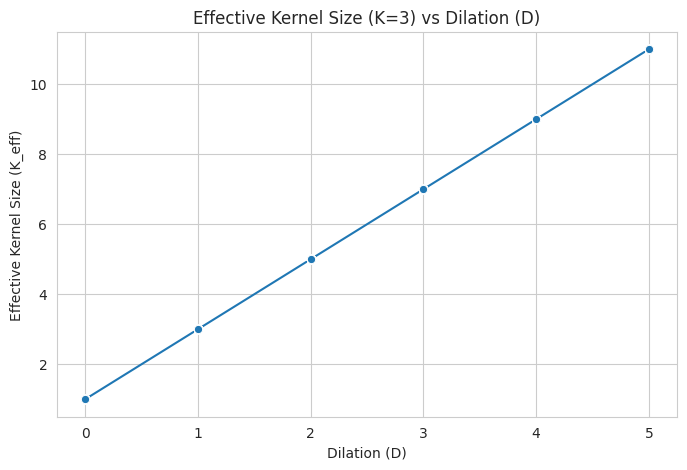


--- Variation of Output Size (O) with Stride, Padding, and Dilation ---



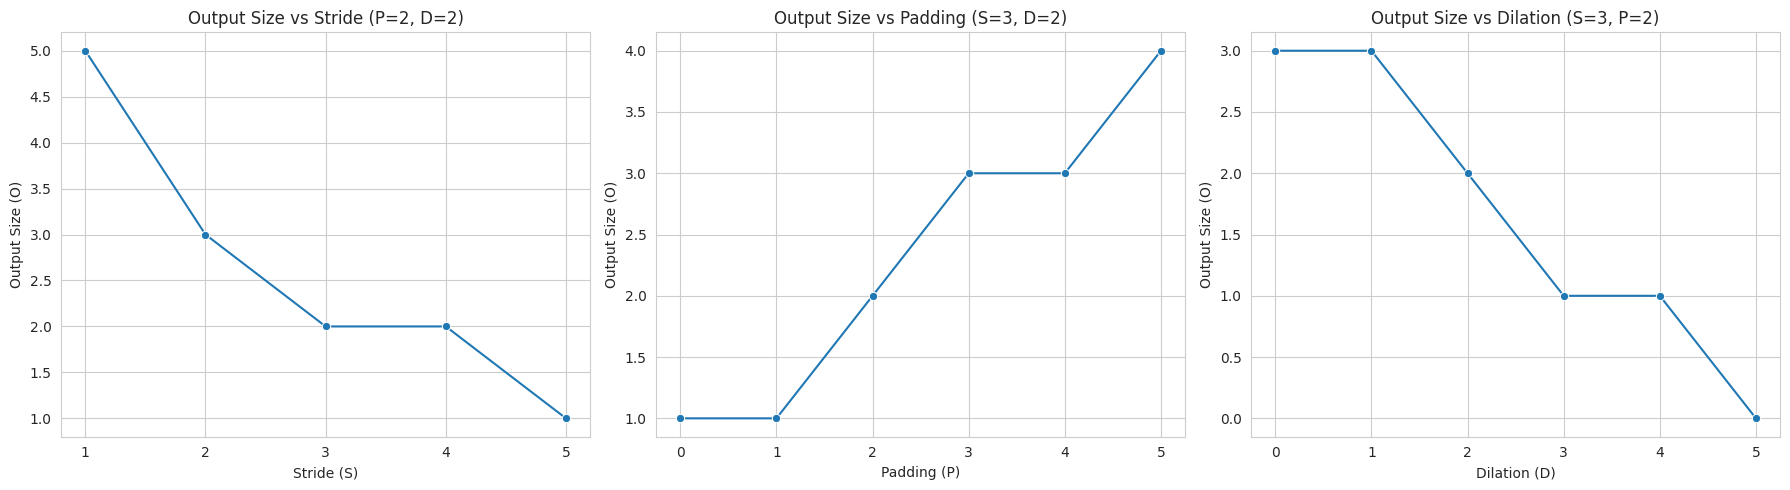


--- Heatmaps for Output Size (O) ---



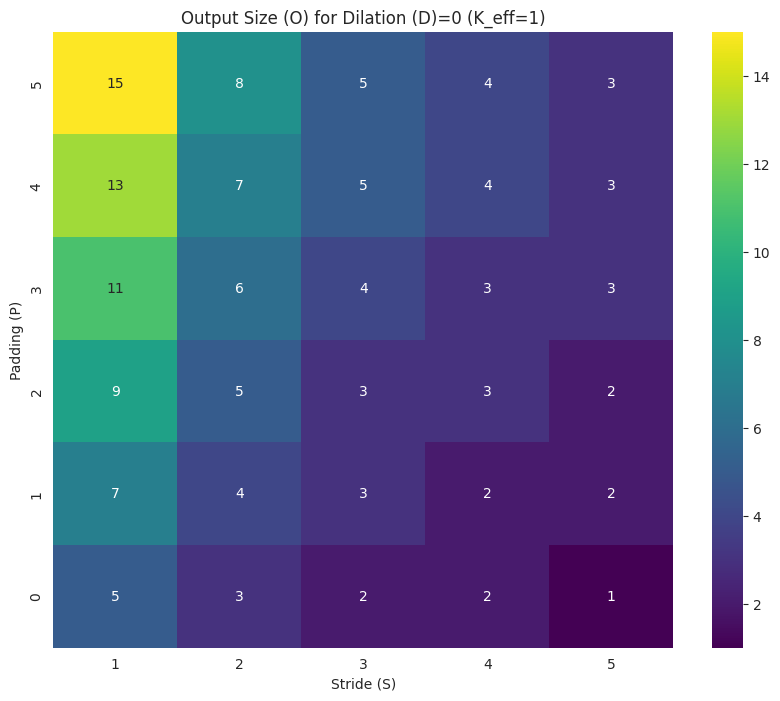

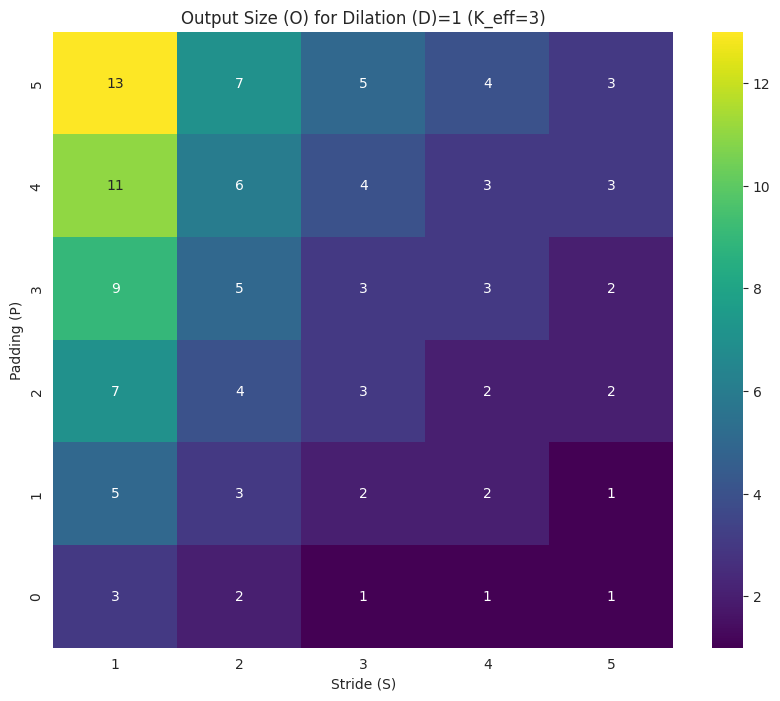

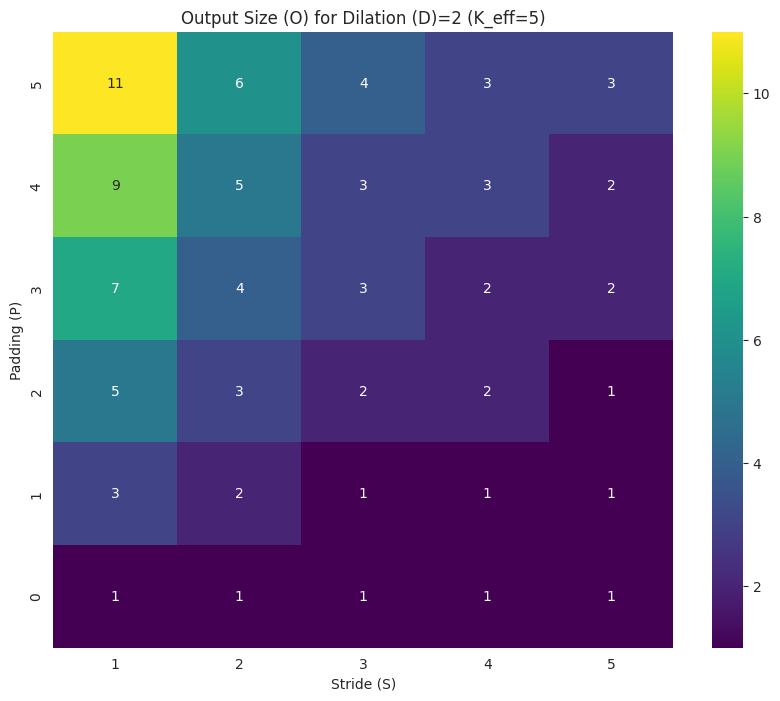

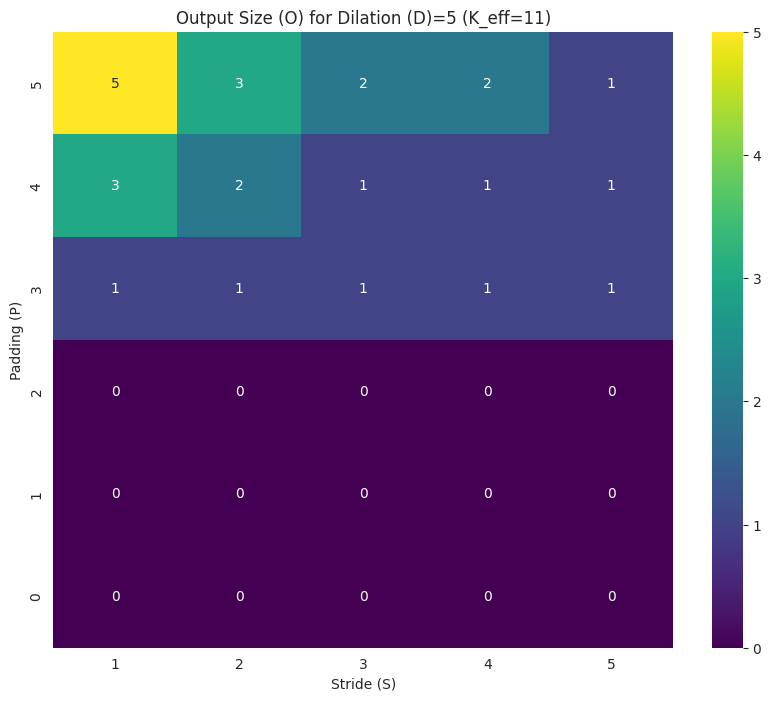

In [8]:
# Input size (I)
I_size_viz = 5
# Original kernel size (K)
K_original_viz = 3

# Setting ranges for Stride (S), Padding (P), Dilation (D)
# Stride cannot be 0 for output calculation, so range from 1 to 5
strides_range = range(1, 6)
# Padding can be 0, so range from 0 to 5
paddings_range = range(0, 6)
# Dilation can be 0, so range from 0 to 5
dilations_range = range(0, 6)
# Note that dilation '0' will shrink the existing kernel, while dilation = '1' will pass kernel as as 3x3

results_viz = []

for S_val in strides_range:
    for P_val in paddings_range:
        for D_val in dilations_range:
            # Calculate Effective Kernel Size (K_eff)
            # Formula: K_eff = K_original + (K_original - 1) * (D - 1)
            # If D_val = 0, (D_val - 1) = -1. So, K_eff = K_original - (K_original - 1) = 1.
            # This means a dilation of 0 makes the effective kernel 1x1, which is a valid mathematical outcome.
            k_eff_viz = K_original_viz + (K_original_viz - 1) * (D_val - 1)

            # Calculate Output Size (O)
            # Formula: O = (N + 2P - K_eff) // S + 1
            numerator = I_size_viz + 2 * P_val - k_eff_viz

            # If the numerator is negative, the effective receptive field is larger than the effective input,
            # meaning no valid convolution can occur, resulting in an output size of 0.
            if numerator < 0:
                output_size_viz = 0
            else:
                output_size_viz = numerator // S_val + 1

            results_viz.append({
                'Stride (S)': S_val,
                'Padding (P)': P_val,
                'Dilation (D)': D_val,
                'Effective Kernel Size (K_eff)': k_eff_viz,
                'Output Size (O)': output_size_viz
            })

df_viz = pd.DataFrame(results_viz)

# --- Plotting ---

# Set a nice style for plots
sns.set_style("whitegrid")

# Plot 1: Effective Kernel Size vs Dilation (K_eff depends only on D and K_original)
plt.figure(figsize=(8, 5))
# Use estimator=None and errorbar=None because K_eff is a direct calculation, not an aggregate
sns.lineplot(data=df_viz, x='Dilation (D)', y='Effective Kernel Size (K_eff)', marker='o', estimator=None, errorbar=None)
plt.title('Effective Kernel Size (K=3) vs Dilation (D)')
plt.xlabel('Dilation (D)')
plt.ylabel('Effective Kernel Size (K_eff)')
plt.xticks(dilations_range)
plt.grid(True)
plt.show()

print("\n--- Variation of Output Size (O) with Stride, Padding, and Dilation ---\n")

# Plot 2: Variation of Output Size with S, P, D (holding two others constant at their median)
# Median values for S (1-5), P (0-5), D (0-5)
S_median = 3 # (1+5)/2 = 3
P_median = 2 # (0+5)/2 = 2.5, floor to 2
D_median = 2 # (0+5)/2 = 2.5, floor to 2

plt.figure(figsize=(18, 5))

# Output Size vs Stride (S)
plt.subplot(1, 3, 1)
sns.lineplot(
    data=df_viz[
        (df_viz['Padding (P)'] == P_median) &
        (df_viz['Dilation (D)'] == D_median)
    ],
    x='Stride (S)', y='Output Size (O)', marker='o'
)
plt.title(f'Output Size vs Stride (P={P_median}, D={D_median})')
plt.xlabel('Stride (S)')
plt.ylabel('Output Size (O)')
plt.xticks(strides_range)
plt.grid(True)

# Output Size vs Padding (P)
plt.subplot(1, 3, 2)
sns.lineplot(
    data=df_viz[
        (df_viz['Stride (S)'] == S_median) &
        (df_viz['Dilation (D)'] == D_median)
    ],
    x='Padding (P)', y='Output Size (O)', marker='o'
)
plt.title(f'Output Size vs Padding (S={S_median}, D={D_median})')
plt.xlabel('Padding (P)')
plt.ylabel('Output Size (O)')
plt.xticks(paddings_range)
plt.grid(True)

# Output Size vs Dilation (D)
plt.subplot(1, 3, 3)
sns.lineplot(
    data=df_viz[
        (df_viz['Stride (S)'] == S_median) &
        (df_viz['Padding (P)'] == P_median)
    ],
    x='Dilation (D)', y='Output Size (O)', marker='o'
)
plt.title(f'Output Size vs Dilation (S={S_median}, P={P_median})')
plt.xlabel('Dilation (D)')
plt.ylabel('Output Size (O)')
plt.xticks(dilations_range)
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n--- Heatmaps for Output Size (O) ---\n")

# Plot 3: Heatmaps for Output Size (O) as a function of (S, P) for specific Dilation values

# Let's pick a few key Dilation values to show the effect
for d_val in [0, 1, 2, 5]: # D=0 (K_eff=1), D=1 (K_eff=3), D=2 (K_eff=5), D=5 (K_eff=11)
    plt.figure(figsize=(10, 8))
    pivot_table_sp = df_viz[(df_viz['Dilation (D)'] == d_val)].pivot_table(
        index='Padding (P)', columns='Stride (S)', values='Output Size (O)'
    )
    sns.heatmap(pivot_table_sp, annot=True, cmap='viridis', fmt='g')
    plt.title(f'Output Size (O) for Dilation (D)={d_val} (K_eff={df_viz[df_viz["Dilation (D)"] == d_val]["Effective Kernel Size (K_eff)"].iloc[0]})')
    plt.ylabel('Padding (P)')
    plt.xlabel('Stride (S)')
    plt.gca().invert_yaxis() # Put P=0 at bottom
    plt.show()

Original Input Size: 5x5
Original Kernel Size: 2x2

--- Layer 1 (using setup parameters S=1, P=1, D=2) ---
  Parameters: Stride (S1)=1, Padding (P1)=1, Dilation (D1)=2
  Effective Kernel Size (K_eff1): 3x3
  Output Size (O1): 5x5
  Receptive Field of one neuron in Layer 1: 3x3 on original input.

--- Layer 2 (assuming S=2, P=0, D=1) ---
  Input Size to Layer 2 (Output of Layer 1): 5x5
  Parameters: Stride (S2)=2, Padding (P2)=0, Dilation (D2)=1
  Effective Kernel Size (K_eff2): 2x2
  Output Size (O2): 2x2
  Receptive Field of one neuron in Layer 2: 4x4 on original input.

--- Layer 3 (assuming S=1, P=0, D=1) ---
  Input Size to Layer 3 (Output of Layer 2): 2x2
  Parameters: Stride (S3)=1, Padding (P3)=0, Dilation (D3)=1
  Effective Kernel Size (K_eff3): 2x2
  Output Size (O3): 1x1
  Receptive Field of one neuron in Layer 3: 6x6 on original input.



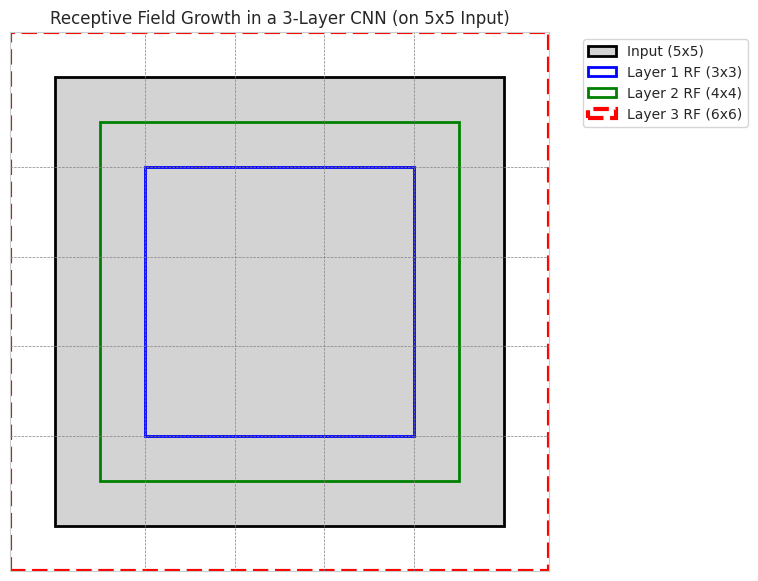


--- Summary of Receptive Field Sizes ---
  Layer 1 Receptive Field: 3x3
  Layer 2 Receptive Field: 4x4
  Layer 3 Receptive Field: 6x6

Note: The 6x6 receptive field of a Layer 3 neuron on the 5x5 input means it covers the entire input image and conceptually extends beyond its borders.


In [9]:
# Helper functions for calculations
def calculate_effective_kernel_size(original_kernel_size, dilation):
    """Calculates the effective kernel size given original size and dilation."""
    # K_eff = K + (K-1)(D-1)
    return original_kernel_size + (original_kernel_size - 1) * (dilation - 1)

def calculate_output_size(input_size, effective_kernel_size, stride, padding):
    """Calculates the output dimension of a convolutional layer."""
    # O = (I + 2P - K_eff) // S + 1
    numerator = input_size + 2 * padding - effective_kernel_size
    if numerator < 0: # Output cannot be negative
        return 0
    return numerator // stride + 1

# --- Core Parameters from Context ---
I_size = 5 # Original Input size (N) is 5x5
K_original = 2 # Original Kernel size (K) is 2x2

print(f"Original Input Size: {I_size}x{I_size}")
print(f"Original Kernel Size: {K_original}x{K_original}\n")

# --- Layer 1: Parameters and Receptive Field Calculation ---
print("--- Layer 1 (using setup parameters S=1, P=1, D=2) ---")
S1 = 1
P1 = 1
D1 = 2
K_eff1 = calculate_effective_kernel_size(K_original, D1)
Output_size1 = calculate_output_size(I_size, K_eff1, S1, P1)
# The receptive field of a neuron in the first layer is its effective kernel size (relative to input pixels)
RF0 = 1 # Receptive field of an input pixel
RF1 = RF0 + (K_eff1 - 1) * 1 # Stride product before Layer 1 is 1

print(f"  Parameters: Stride (S1)={S1}, Padding (P1)={P1}, Dilation (D1)={D1}")
print(f"  Effective Kernel Size (K_eff1): {K_eff1}x{K_eff1}")
print(f"  Output Size (O1): {Output_size1}x{Output_size1}")
print(f"  Receptive Field of one neuron in Layer 1: {RF1}x{RF1} on original input.\n")

# --- Layer 2: Parameters and Receptive Field Calculation ---
print("--- Layer 2 (assuming S=2, P=0, D=1) ---")
S2 = 2
P2 = 0
D2 = 1 # Dilation 1 means no actual dilation, K_eff = K_original
K_eff2 = calculate_effective_kernel_size(K_original, D2)
Output_size2 = calculate_output_size(Output_size1, K_eff2, S2, P2)
# RF for layer 2: RF_prev + (K_eff_curr - 1) * S_prev
RF2 = RF1 + (K_eff2 - 1) * S1 # S1 is the stride of the *previous* layer (Layer 1)

print(f"  Input Size to Layer 2 (Output of Layer 1): {Output_size1}x{Output_size1}")
print(f"  Parameters: Stride (S2)={S2}, Padding (P2)={P2}, Dilation (D2)={D2}")
print(f"  Effective Kernel Size (K_eff2): {K_eff2}x{K_eff2}")
print(f"  Output Size (O2): {Output_size2}x{Output_size2}")
print(f"  Receptive Field of one neuron in Layer 2: {RF2}x{RF2} on original input.\n")

# --- Layer 3: Parameters and Receptive Field Calculation ---
print("--- Layer 3 (assuming S=1, P=0, D=1) ---")
S3 = 1
P3 = 0
D3 = 1
K_eff3 = calculate_effective_kernel_size(K_original, D3)
Output_size3 = calculate_output_size(Output_size2, K_eff3, S3, P3)
# RF for layer 3: RF_prev + (K_eff_curr - 1) * (S_prev_1 * S_prev_2)
RF3 = RF2 + (K_eff3 - 1) * (S1 * S2) # S1*S2 is the product of strides of previous layers

print(f"  Input Size to Layer 3 (Output of Layer 2): {Output_size2}x{Output_size2}")
print(f"  Parameters: Stride (S3)={S3}, Padding (P3)={P3}, Dilation (D3)={D3}")
print(f"  Effective Kernel Size (K_eff3): {K_eff3}x{K_eff3}")
print(f"  Output Size (O3): {Output_size3}x{Output_size3}")
print(f"  Receptive Field of one neuron in Layer 3: {RF3}x{RF3} on original input.\n")

# --- Visualization of Receptive Fields ---
fig, ax = plt.subplots(figsize=(7, 7))

# Draw the 5x5 input grid (conceptual cells from 0 to 4)
ax.add_patch(patches.Rectangle((0, 0), I_size, I_size, edgecolor='black', facecolor='lightgray', linewidth=2, label=f'Input ({I_size}x{I_size})'))

# Draw grid lines for input cells
for i in range(1, I_size): # Lines at 1, 2, 3, 4
    ax.axvline(i, color='gray', linestyle='--', linewidth=0.5)
    ax.axhline(i, color='gray', linestyle='--', linewidth=0.5)

# Function to calculate centered position for a rectangle
def get_centered_coords(total_size, rect_size):
    start = (total_size - rect_size) / 2.0
    return start

# RF1 (3x3) on 5x5 input
offset_rf1_x = get_centered_coords(I_size, RF1)
offset_rf1_y = get_centered_coords(I_size, RF1)
ax.add_patch(patches.Rectangle((offset_rf1_x, offset_rf1_y), RF1, RF1, edgecolor='blue', facecolor='none', linewidth=2, label=f'Layer 1 RF ({RF1}x{RF1})'))

# RF2 (4x4) on 5x5 input
offset_rf2_x = get_centered_coords(I_size, RF2)
offset_rf2_y = get_centered_coords(I_size, RF2)
ax.add_patch(patches.Rectangle((offset_rf2_x, offset_rf2_y), RF2, RF2, edgecolor='green', facecolor='none', linewidth=2, label=f'Layer 2 RF ({RF2}x{RF2})'))

# RF3 (6x6) on 5x5 input - it will exceed the input boundary, showing it covers the entire input.
offset_rf3_x = get_centered_coords(I_size, RF3)
offset_rf3_y = get_centered_coords(I_size, RF3)
ax.add_patch(patches.Rectangle((offset_rf3_x, offset_rf3_y), RF3, RF3, edgecolor='red', facecolor='none', linewidth=3, linestyle='--', label=f'Layer 3 RF ({RF3}x{RF3})'))

ax.set_xlim(-0.5, I_size + 0.5) # Add some margin
ax.set_ylim(-0.5, I_size + 0.5)
ax.set_xticks(np.arange(0, I_size + 1, 1)) # Ticks at grid boundaries
ax.set_yticks(np.arange(0, I_size + 1, 1))
ax.set_xticklabels([]) # No labels for conceptual grid
ax.set_yticklabels([])
ax.set_aspect('equal', adjustable='box') # Maintain square aspect ratio
ax.set_title('Receptive Field Growth in a 3-Layer CNN (on 5x5 Input)')
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.grid(False)
plt.show()

print("\n--- Summary of Receptive Field Sizes ---")
print(f"  Layer 1 Receptive Field: {RF1}x{RF1}")
print(f"  Layer 2 Receptive Field: {RF2}x{RF2}")
print(f"  Layer 3 Receptive Field: {RF3}x{RF3}")
print("\nNote: The 6x6 receptive field of a Layer 3 neuron on the 5x5 input means it covers the entire input image and conceptually extends beyond its borders.")


The plot visually illustrates this expansion. Notice how the blue square (Layer 1) covers a 3x3 area, the green square (Layer 2) covers a 4x4 area, and the red dashed square (Layer 3) covers a 6x6 area. This 6x6 area conceptually extends beyond the 5x5 input boundary, meaning that a single neuron in the third layer effectively "sees" the entire original input image and beyond.

This demonstrates how deeper layers in a CNN can capture increasingly broader contextual information from the input.

#Conclusion

This walkthrough notebook was developed to visualize and describe the basic convolution computations and spatial arithmetic. Thes form the basic building blocks of CNNs.

By experimenting through the parameters settings for padding `(P)`, Stride `(S)` and Dilation `(D)` we visualize the impact on the size of the output `(O)` and the effective result of the computation, ie; the influence of the receptive field RF on the element-wise computation of the matrices.



---


